In [160]:
# 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from workalendar.asia import SouthKorea 

# statsmodel 확인
from pmdarima import auto_arima
from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from multiprocessing import Pool, cpu_count
from torch.utils.data import DataLoader, TensorDataset

# 오류 무시하는 방법
import warnings
warnings.filterwarnings("ignore")
from sklearn.preprocessing import MinMaxScaler

In [161]:
df_sarima = pd.read_csv("/mnt/nvme/hybrid/SCI/sarima_prediction.csv")
df_real = pd.read_csv("/mnt/nvme/hybrid/SCI/power_demand_final.csv")
df_cnn_lstm = pd.read_csv("/mnt/nvme/hybrid/cnn_lstm.iter100.csv")
df_lstm = pd.read_csv("/mnt/nvme/hybrid/lstm_iteration_100.csv")
df_sarima_cnn_lstm = pd.read_csv("/mnt/nvme/hybrid/SCI/hybrid_model_iter100.csv")

df_real1 = df_real[-len(df_cnn_lstm):]
# 
df_sarima = df_sarima[-len(df_cnn_lstm):]

In [162]:
df_result_pred = pd.DataFrame()
df_result_pred["real"] = df_real1["power demand(MW)"].values
df_result_pred["lstm"] = df_lstm["0"]
df_result_pred["sarima_cnn_lstm"] = df_sarima_cnn_lstm["0"]
df_result_pred["cnn_lstm"] = df_cnn_lstm["0"]
df_result_pred["sarima"] = df_sarima["0"].values
# df_result_pred["sarimax"] = df_sarima["sarimax"].values

df_result_pred["일시"] = pd.to_datetime(df_real1["일시"].values)

In [163]:
df_result_pred.set_index("일시", inplace=True)

In [164]:
def smape(y_true, y_pred):
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
    diff = np.abs(y_true - y_pred)
    # 0/0 방지를 위해 denominator가 0인 경우는 0으로 처리
    return np.mean(np.where(denominator == 0, 0, diff / denominator)) * 100


In [165]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

# RMSE 계산 함수
def root_mean_squared_error(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def calculate_metrics(df):
    models = ["sarima_cnn_lstm", "lstm", "cnn_lstm", "sarima"]
    metrics_summary = []

    for model in models:
        y_true = df["real"].values
        y_pred = df[model].values

        r2 = r2_score(y_true, y_pred)
        mse = mean_squared_error(y_true, y_pred)
        rmse = root_mean_squared_error(y_true, y_pred)
        mae = mean_absolute_error(y_true, y_pred)
        smape_val = smape(y_true, y_pred)

        metrics_summary.append({
            "Model": model,
            "R2 Score": r2,
            "MSE": mse,
            "RMSE": rmse,
            "MAE": mae,
            "SMAPE": smape_val
        })

    return pd.DataFrame(metrics_summary)

In [166]:
calculate_metrics(df_result_pred)

,Model,R2 Score,MSE,RMSE,MAE,SMAPE
0,sarima_cnn_lstm,0.980767,2.277664e+06,1509.193024,1056.514874,1.678287
1,lstm,0.888990,1.314658e+07,3625.821043,2730.149485,4.200048
2,cnn_lstm,0.894502,1.249380e+07,3534.656379,2559.252166,3.900521
3,sarima,0.614223,4.568639e+07,6759.170673,4515.547467,6.993264


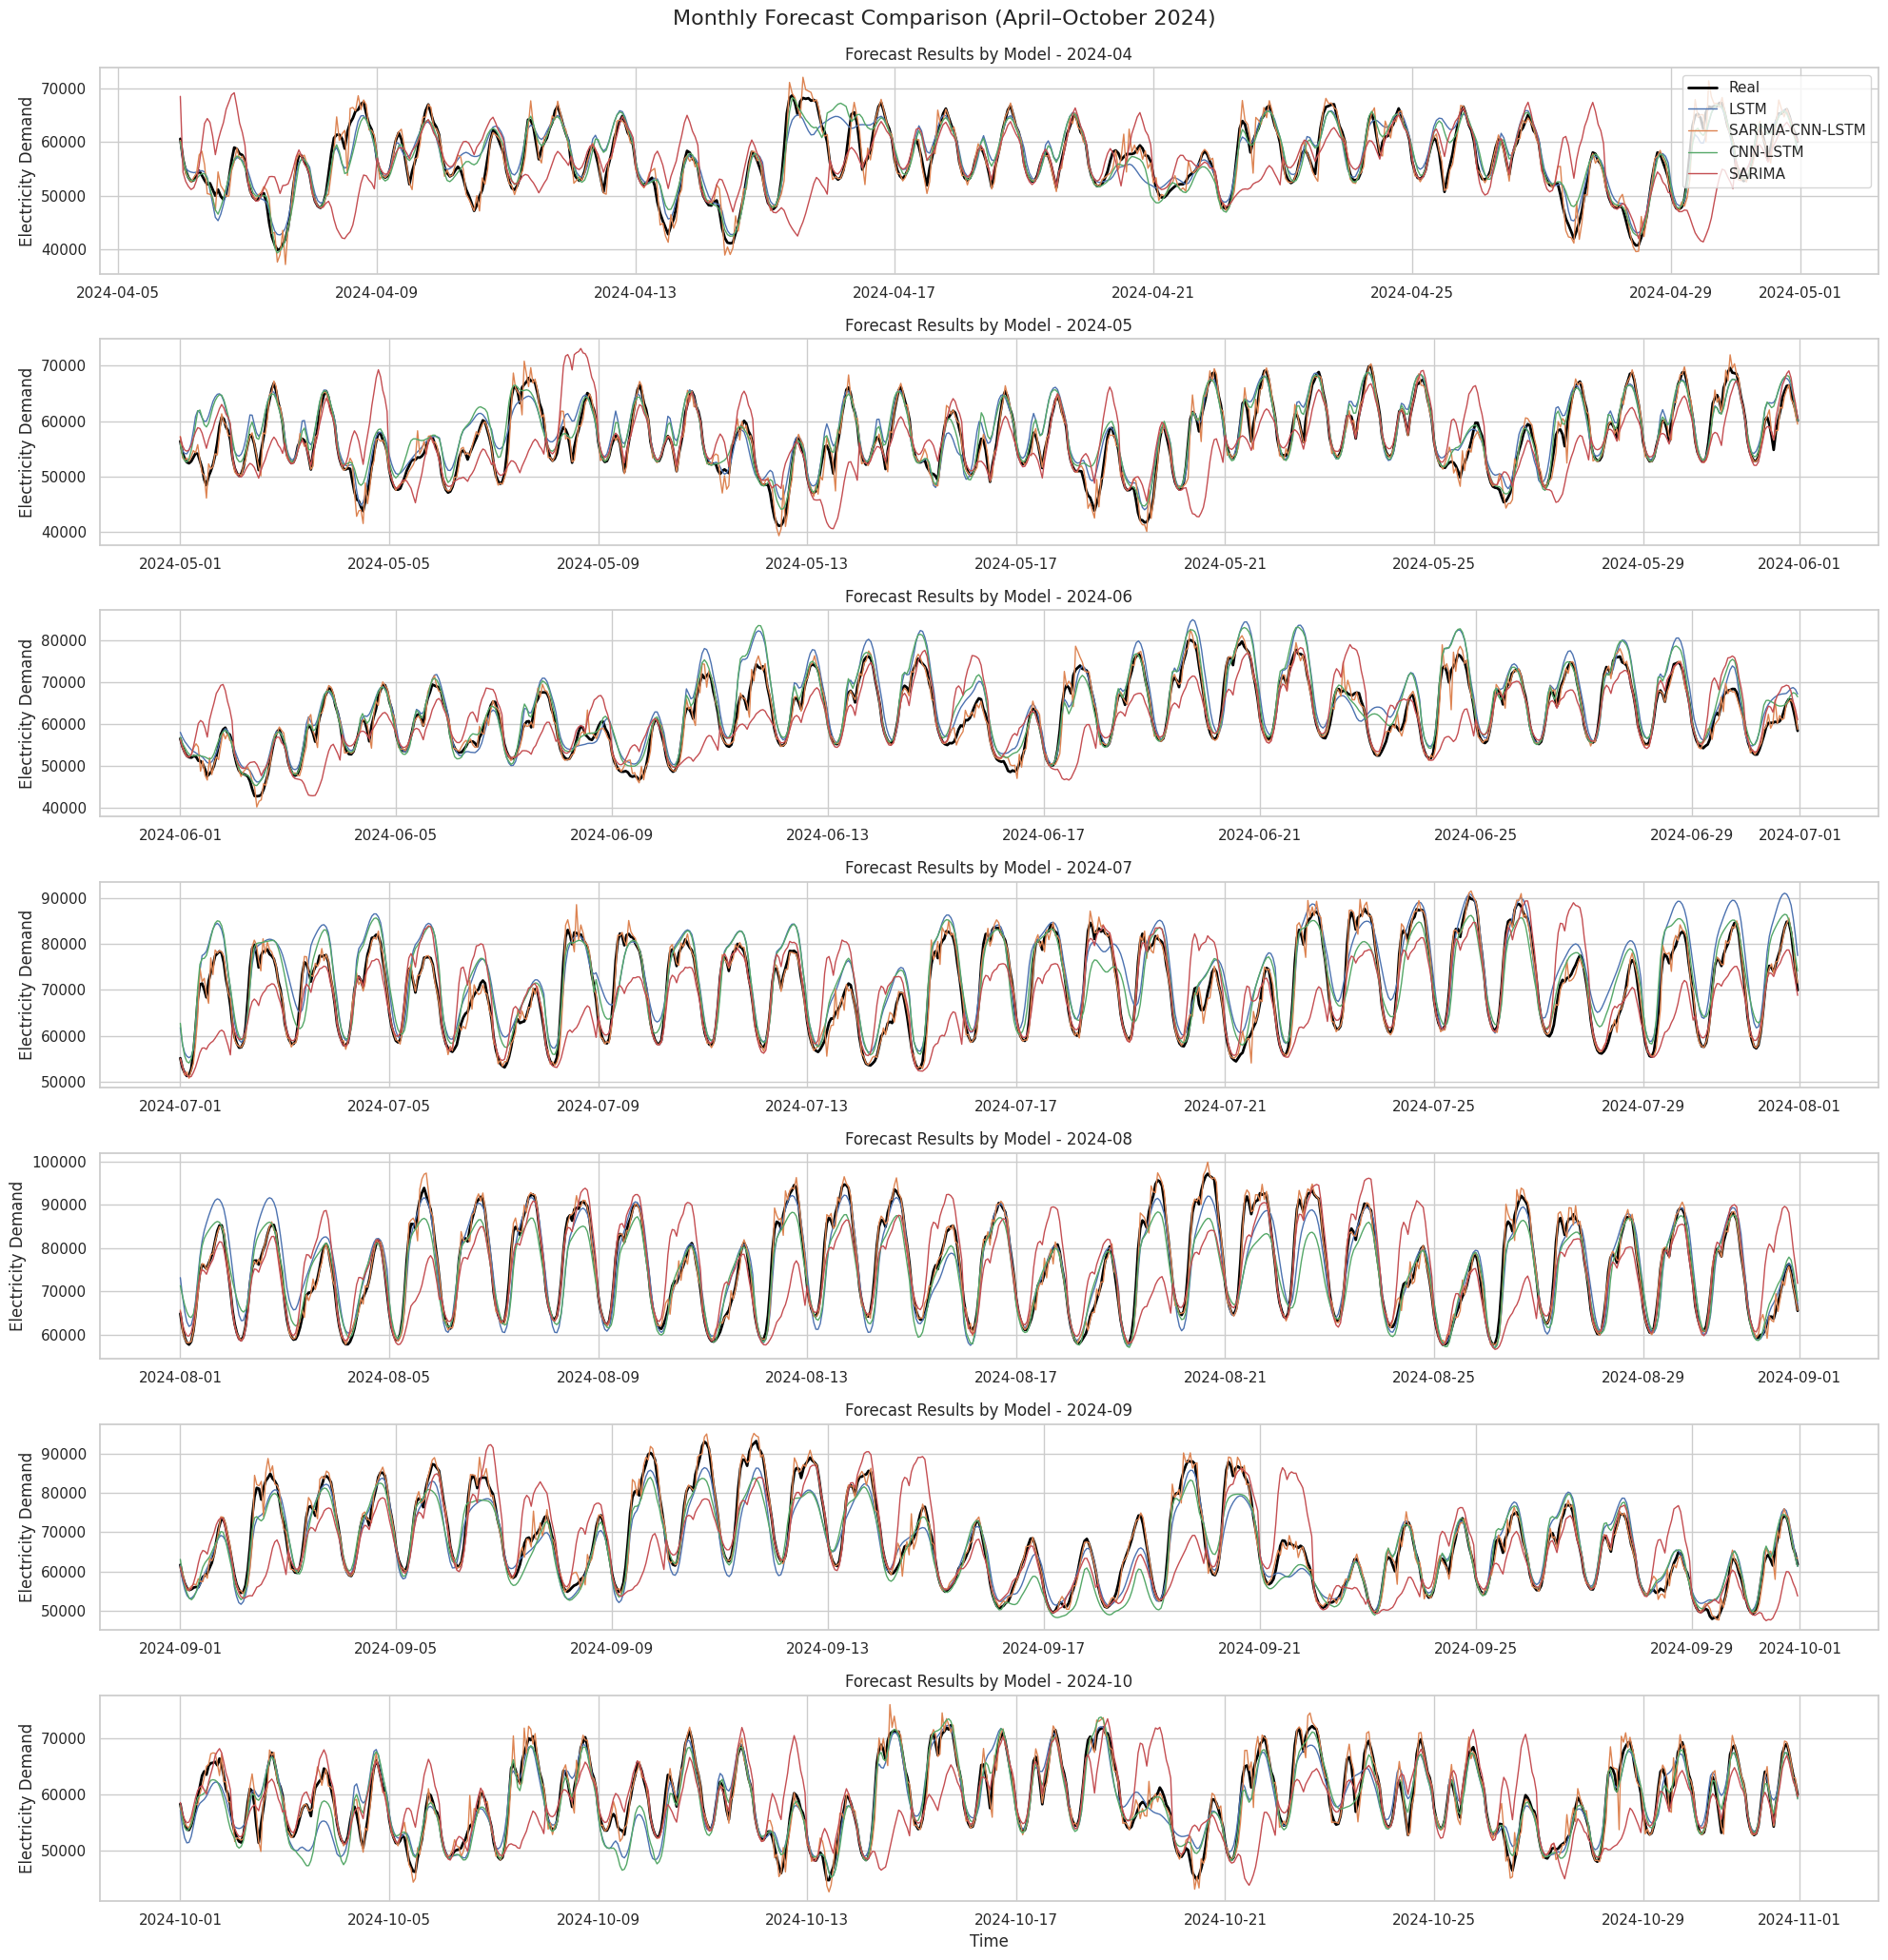

In [167]:
# 올바른 서브플롯 구조로 전체 7개월(2024-04 ~ 2024-10)을 세로로 나열 (7행 1열)

# 모델 리스트 및 라벨
model_list = ["lstm", "sarima_cnn_lstm", "cnn_lstm", "sarima"]
titles = ["LSTM", "SARIMA-CNN-LSTM", "CNN-LSTM", "SARIMA"]

# 월 컬럼 추가
df_result_pred["month"] = df_result_pred.index.to_period("M")

# 월 순서 지정
selected_months = sorted(df_result_pred["month"].unique())[:7]

# 서브플롯 생성
fig, axs = plt.subplots(len(selected_months), 1, figsize=(20, 3 * len(selected_months)), sharex=False)

for i, month in enumerate(selected_months):
    group = df_result_pred[df_result_pred["month"] == month]
    ax = axs[i]
    ax.plot(group.index, group["real"], label="Real", color="black", linewidth=2)
    for model, title in zip(model_list, titles):
        ax.plot(group.index, group[model], label=title, linewidth=1)
    ax.set_title(f"Forecast Results by Model - {month}", fontsize=12)
    ax.set_ylabel("Electricity Demand")
    ax.grid(True)
    if i == 0:
        ax.legend(loc="upper right")

plt.xlabel("Time")
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.suptitle("Monthly Forecast Comparison (April–October 2024)", fontsize=16)
plt.show()


In [169]:
df_real2

,일시,hm,ta,power demand(MW),holiday_name,weekday,weekend,spring,summer,autoum,winter,is_holiday_dummies
17544,2021-01-01 00:00:00,74.862169,-6.370168,64942.0,New Year's Day,0,1,0,0,0,1,1
17545,2021-01-01 01:00:00,76.185273,-6.866279,62593.0,New Year's Day,0,1,0,0,0,1,1
17546,2021-01-01 02:00:00,77.157937,-7.237707,60905.0,New Year's Day,0,1,0,0,0,1,1
17547,2021-01-01 03:00:00,77.803968,-7.481287,59889.0,New Year's Day,0,1,0,0,0,1,1
17548,2021-01-01 04:00:00,78.406085,-7.899921,59638.0,New Year's Day,0,1,0,0,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...
51139,2024-10-31 19:00:00,75.547619,15.667637,67551.0,day,1,0,0,0,1,0,0
51140,2024-10-31 20:00:00,79.587125,14.787954,65341.0,day,1,0,0,0,1,0,0
51141,2024-10-31 21:00:00,82.265079,14.053263,63341.0,day,1,0,0,0,1,0,0
51142,2024-10-31 22:00:00,84.185538,13.475044,62031.0,day,1,0,0,0,1,0,0


In [168]:
# 추석 설 연휴 그래프 생성
import seaborn as sns


# 2021 슬라이싱 후 그래프 생성
df_real2 = df_real[df_real["일시"]>="2021-01-01"]
df_real2["일시"] = pd.to_datetime(df_real2["일시"])

# 'Chuseok' 또는 'Korean New Year' 여부를 기준으로 새 컬럼 추가
df_real2["holiday_name"].fillna("day", inplace=True)

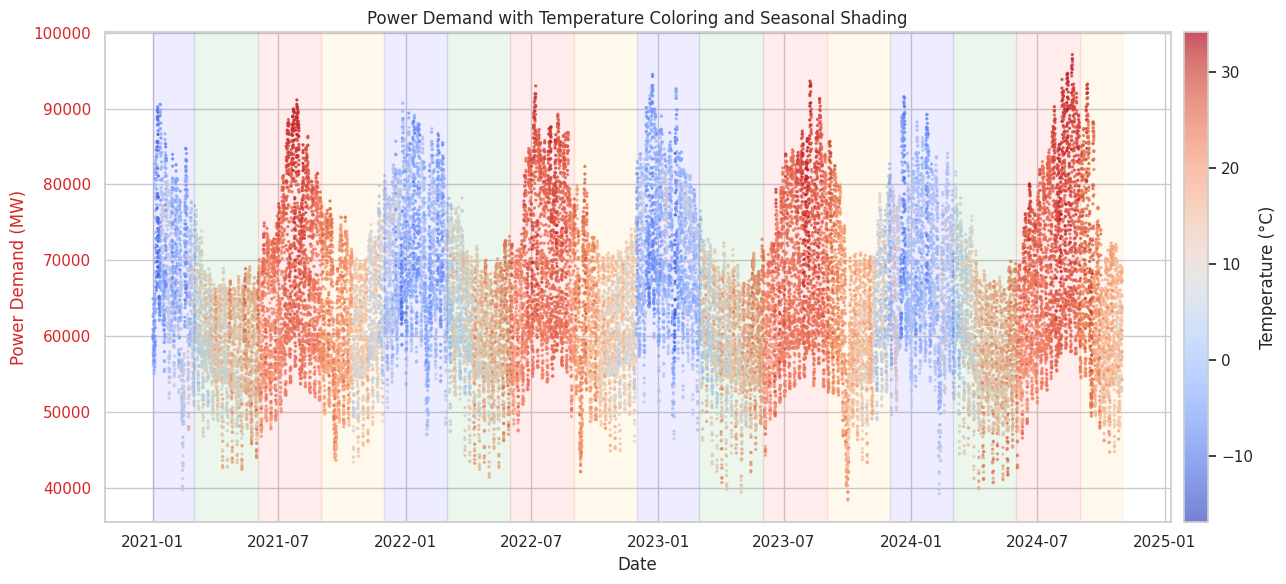

In [65]:
import matplotlib.pyplot as plt

# 기본 세팅
fig, ax = plt.subplots(figsize=(14, 6))

# 산점도: 전력수요 vs 시간, 색상은 기온
scatter = ax.scatter(df_real2['일시'],
                     df_real2['power demand(MW)'],
                     c=df_real2['ta'],                # 색상 = 기온
                     cmap='coolwarm',                # 색상 팔레트
                     s=2,
                     alpha=0.7)

ax.set_ylabel('Power Demand (MW)', color='tab:red')
ax.set_xlabel('Date')
ax.tick_params(axis='y', labelcolor='tab:red')

# 색상범례 (기온)
cbar = plt.colorbar(scatter, ax=ax, pad=0.01)
cbar.set_label('Temperature (°C)')

# 계절별 배경 색 지정
season_colors = {
    'spring': 'green',
    'summer': 'red',
    'autoum': 'orange',
    'winter': 'blue'
}

for season, color in season_colors.items():
    mask = df_real2[season] == 1
    if mask.any():
        ranges = []
        start = None
        for i in range(len(mask)):
            if mask.iloc[i] and start is None:
                start = i
            elif not mask.iloc[i] and start is not None:
                ranges.append((start, i - 1))
                start = None
        if start is not None:
            ranges.append((start, len(mask) - 1))
        for start, end in ranges:
            ax.axvspan(df_real2['일시'].iloc[start],
                       df_real2['일시'].iloc[end],
                       color=color,
                       alpha=0.07)

# 제목
plt.title('Power Demand with Temperature Coloring and Seasonal Shading')
plt.tight_layout()
plt.show()



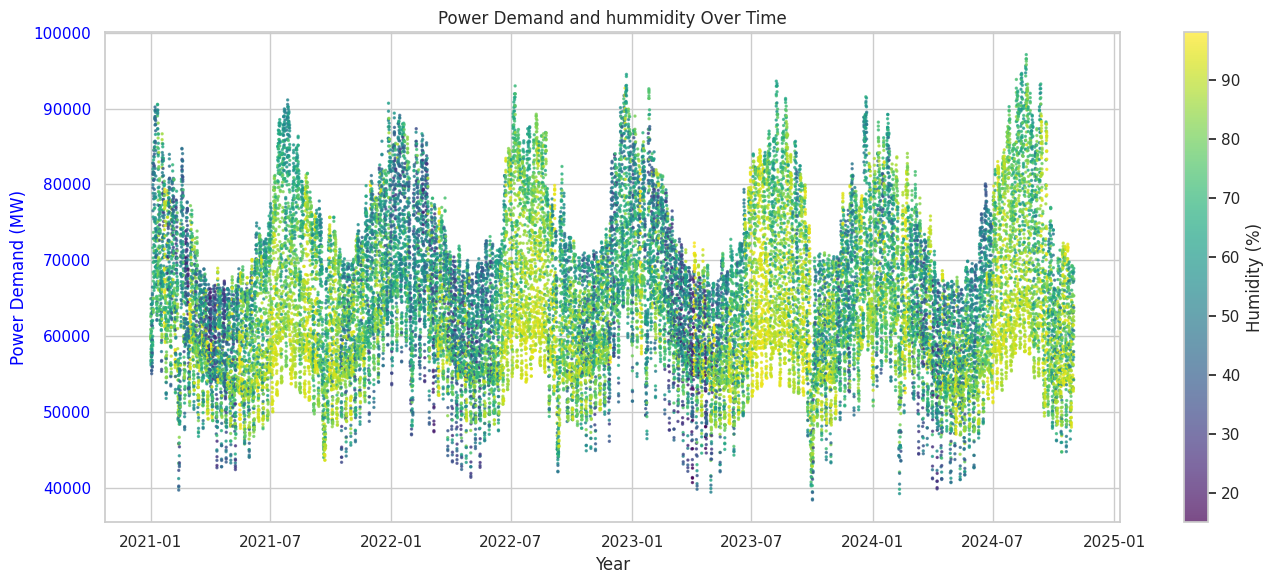

In [66]:
import matplotlib.pyplot as plt

# 예시: 일시 = x축, power = y축, humidity = 색상
fig, ax1 = plt.subplots(figsize=(14, 6))

# 산점도: 습도를 색으로 표현
scatter = ax1.scatter(df_real2['일시'], 
                      df_real2['power demand(MW)'],
                      c=df_real2['hm'],
                      cmap='viridis',   # 컬러맵 선택: 'viridis', 'plasma', 'coolwarm' 등 가능
                      s=2,              # 점 크기
                      alpha=0.7)

# y축 및 라벨
ax1.set_ylabel('Power Demand (MW)', color='blue')
ax1.set_xlabel('Year')
ax1.tick_params(axis='y', labelcolor='blue')
plt.title('Power Demand and hummidity Over Time')

# 컬러바로 습도 범위 표시
cbar = plt.colorbar(scatter, ax=ax1)
cbar.set_label('Humidity (%)')

plt.tight_layout()
plt.show()



In [70]:
df_real2

,일시,hm,ta,power demand(MW),holiday_name,weekday,weekend,spring,summer,autoum,winter,is_holiday_dummies
17544,2021-01-01 00:00:00,74.862169,-6.370168,64942.0,New Year's Day,0,1,0,0,0,1,1
17545,2021-01-01 01:00:00,76.185273,-6.866279,62593.0,New Year's Day,0,1,0,0,0,1,1
17546,2021-01-01 02:00:00,77.157937,-7.237707,60905.0,New Year's Day,0,1,0,0,0,1,1
17547,2021-01-01 03:00:00,77.803968,-7.481287,59889.0,New Year's Day,0,1,0,0,0,1,1
17548,2021-01-01 04:00:00,78.406085,-7.899921,59638.0,New Year's Day,0,1,0,0,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...
51139,2024-10-31 19:00:00,75.547619,15.667637,67551.0,day,1,0,0,0,1,0,0
51140,2024-10-31 20:00:00,79.587125,14.787954,65341.0,day,1,0,0,0,1,0,0
51141,2024-10-31 21:00:00,82.265079,14.053263,63341.0,day,1,0,0,0,1,0,0
51142,2024-10-31 22:00:00,84.185538,13.475044,62031.0,day,1,0,0,0,1,0,0


In [73]:
np.unique(df_real2["holiday_name"].values)

array(["Alternative holiday for Buddha's Birthday",
       "Alternative holiday for Children's Day",
       'Alternative holiday for Chuseok',
       'Alternative holiday for Hangul Day',
       'Alternative holiday for Korean New Year',
       'Alternative holiday for Liberation Day',
       'Alternative holiday for National Foundation Day',
       'Armed Forces Day', "Buddha's Birthday", "Children's Day",
       'Christmas Day', 'Chuseok', 'Hangul Day',
       'Independence Movement Day', 'Korean New Year', 'Liberation Day',
       'Local Election Day', 'Memorial Day',
       'National Assembly Election Day', 'National Foundation Day',
       "New Year's Day", 'Presidential Election Day',
       'Temporary Public Holiday', 'The day preceding Chuseok',
       'The day preceding Korean New Year', 'The second day of Chuseok',
       'The second day of Korean New Year', 'day'], dtype=object)

In [88]:
labels = np.unique(df_real2["holiday_name"].values)

import pandas as pd
import numpy as np

# 원본 데이터 (dtype=object 배열)
labels = np.array(["Alternative holiday for Buddha's Birthday",
       "Alternative holiday for Children's Day",
       'Alternative holiday for Chuseok',
       'Alternative holiday for Hangul Day',
       'Alternative holiday for Korean New Year',
       'Alternative holiday for Liberation Day',
       'Alternative holiday for National Foundation Day',
       'Armed Forces Day', "Buddha's Birthday", "Children's Day",
       'Christmas Day', 'Chuseok', 'Hangul Day',
       'Independence Movement Day', 'Korean New Year', 'Liberation Day',
       'Local Election Day', 'Memorial Day',
       'National Assembly Election Day', 'National Foundation Day',
       "New Year's Day", 'Presidential Election Day',
       'Temporary Public Holiday', 'The day preceding Chuseok',
       'The day preceding Korean New Year', 'The second day of Chuseok',
       'The second day of Korean New Year', 'day'])

# DataFrame 생성

# 'is_korean_newyear_or_chuseok' 열 추가
df_real2['is_korean_newyear_or_chuseok'] = df_real2['holiday_name'].str.contains('Chuseok|Korean New Year|Temporary Public Holiday|National Foundation Day|Hangul Day')


<Axes: xlabel='일시', ylabel='power demand(MW)'>

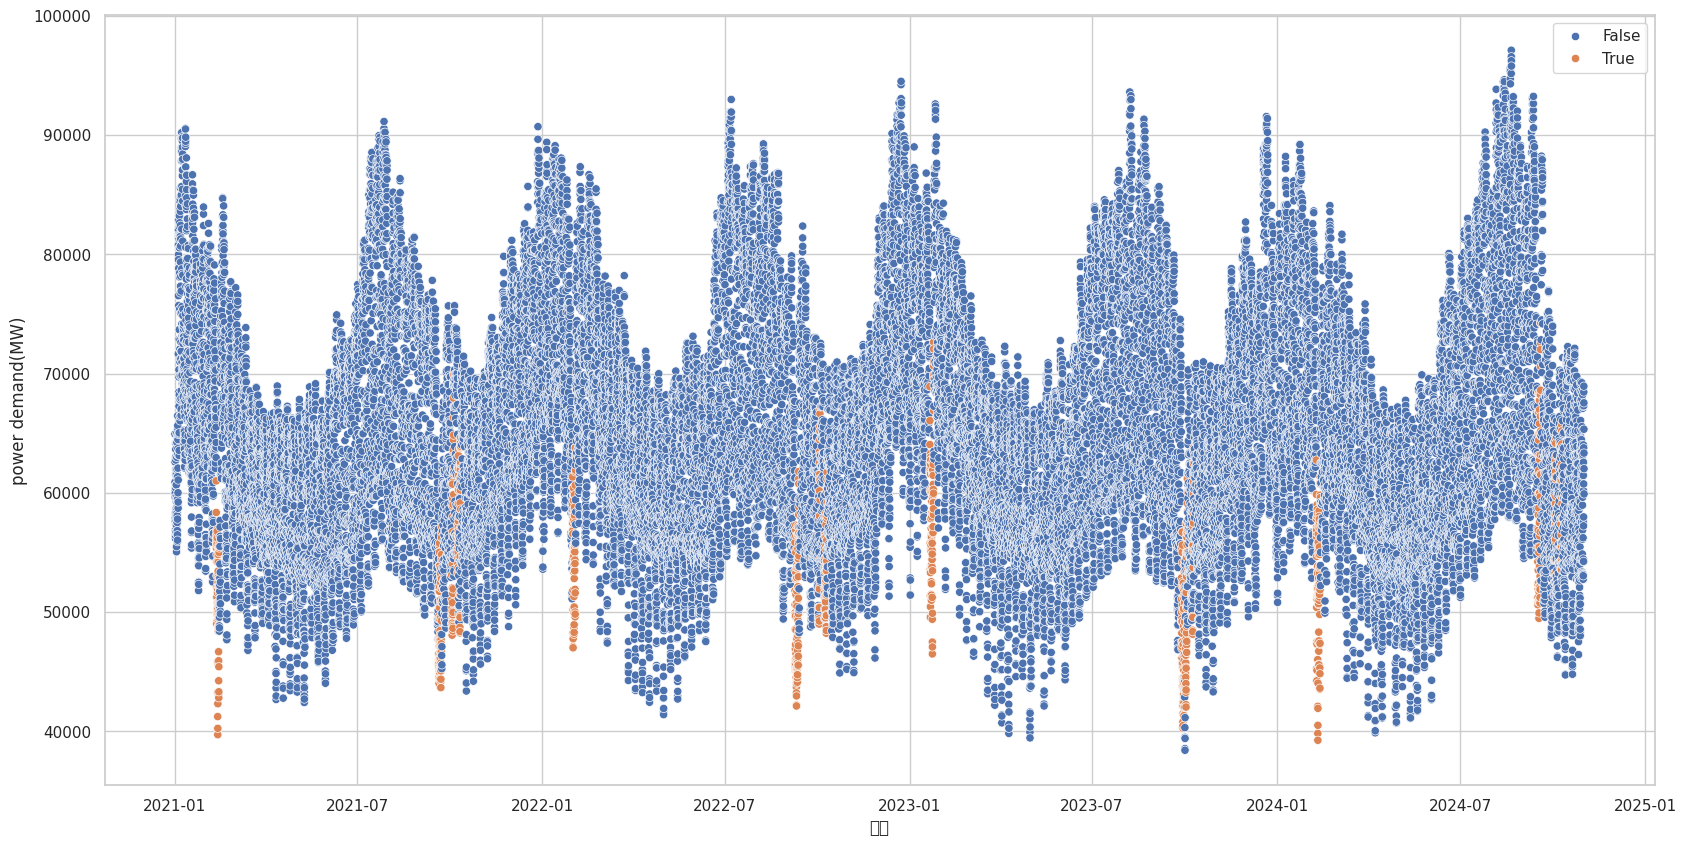

In [89]:
plt.figure(figsize=(20,10))
sns.scatterplot(x=df_real2["일시"], y=df_real2["power demand(MW)"], hue = df_real2["is_korean_newyear_or_chuseok"].values)

In [102]:
df_real2.set_index("일시", inplace=True)

In [128]:
df_real2_ex = df_real2[(df_real2.index>="2022-12-01") & (df_real2.index<"2023-12-01")]
df_real2_ex.reset_index(inplace=True)

In [129]:
df_real2_ex["season"] = df_real2_ex[["spring", "summer", "autoum", "winter"]].idxmax(axis=1)

df_real2_ex["day_type"] = df_real2_ex["weekday"].map({1: "weekday", 0: "weekend"})


In [136]:
df_real2_ex

,일시,hm,ta,power demand(MW),holiday_name,weekday,weekend,spring,summer,autoum,winter,is_holiday_dummies,is_korean_newyear_or_chuseok,season,day_type
0,2022-12-01 00:00:00,56.617560,-5.131637,67600.0,day,1,0,0,0,0,1,0,False,winter,weekday
1,2022-12-01 01:00:00,53.329762,-5.181667,65168.0,day,1,0,0,0,0,1,0,False,winter,weekday
2,2022-12-01 02:00:00,50.286905,-5.269940,63772.0,day,1,0,0,0,0,1,0,False,winter,weekday
3,2022-12-01 03:00:00,48.692857,-5.443155,63109.0,day,1,0,0,0,0,1,0,False,winter,weekday
4,2022-12-01 04:00:00,46.153869,-5.622708,63592.0,day,1,0,0,0,0,1,0,False,winter,weekday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8755,2023-11-30 19:00:00,56.410714,-2.465476,78532.0,day,1,0,0,0,1,0,0,False,autoum,weekday
8756,2023-11-30 20:00:00,58.095238,-2.737500,75190.0,day,1,0,0,0,1,0,0,False,autoum,weekday
8757,2023-11-30 21:00:00,60.404762,-3.185119,72486.0,day,1,0,0,0,1,0,0,False,autoum,weekday
8758,2023-11-30 22:00:00,61.434524,-3.462500,71741.0,day,1,0,0,0,1,0,0,False,autoum,weekday


Text(0.5, 1.0, 'Hourly Power Demand by Day Type with Seasonal Context ')

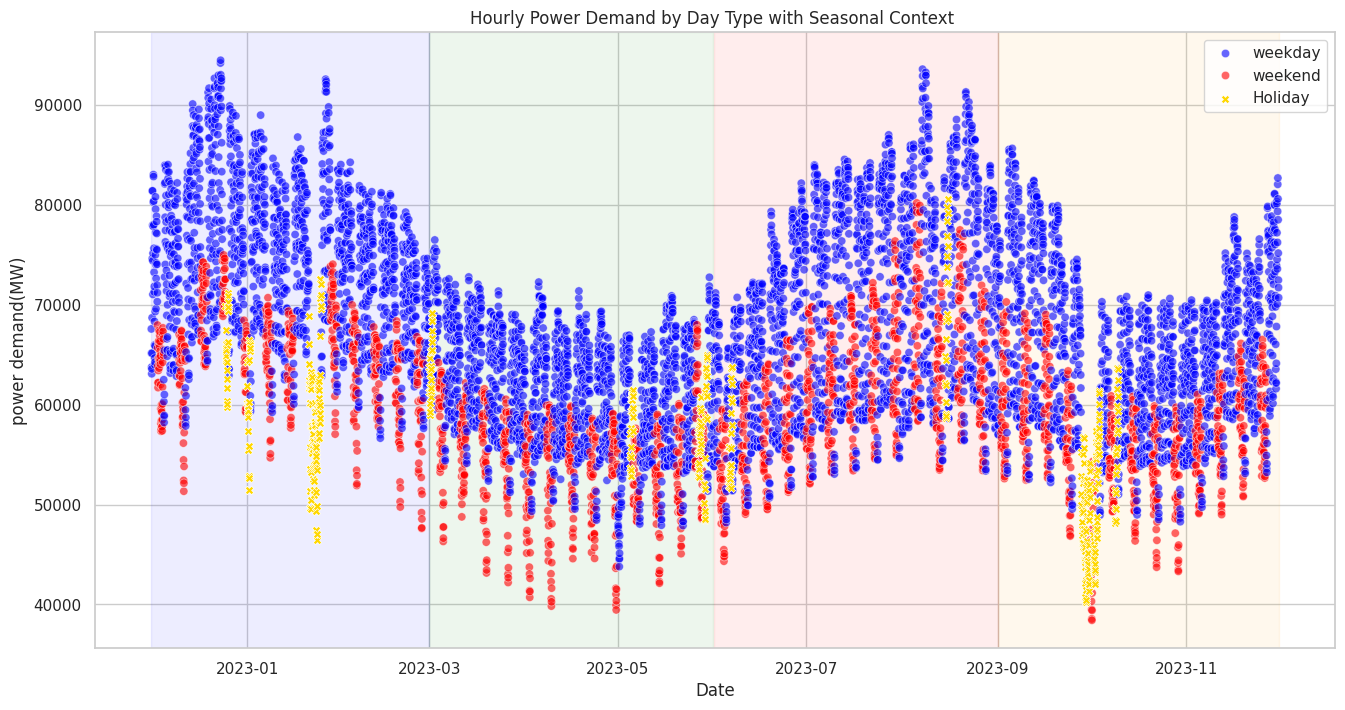

In [191]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(16, 8))

ax = plt.gca()

# 계절 배경 연하게
for season, color in season_colors.items():
    mask = df_real2_ex["season"] == season
    start_idx = None
    for i in range(len(mask)):
        if mask.iloc[i] and start_idx is None:
            start_idx = i
        elif not mask.iloc[i] and start_idx is not None:
            ax.axvspan(df_real2_ex["일시"].iloc[start_idx],
                       df_real2_ex["일시"].iloc[i - 1],
                       color=color, alpha=0.07)
            start_idx = None
    if start_idx is not None:
        ax.axvspan(df_real2_ex["일시"].iloc[start_idx],
                   df_real2_ex["일시"].iloc[-1],
                   color=color, alpha=0.07)

# 🎯 평일/주말 점 그리기
sns.scatterplot(
    data=df_real2_ex[df_real2_ex["holiday_name"] == "day"],
    x="일시",
    y="power demand(MW)",
    hue="day_type",
    palette={"weekday": "blue", "weekend": "red"},
    ax=ax,

    alpha=0.6
)

# 🎯 특정 공휴일 강조 (예: New Year's Day)
sns.scatterplot(
    data=df_real2_ex[df_real2_ex["holiday_name"]!="day"],
    x="일시",
    y="power demand(MW)",
    label="Holiday",
    color="gold",
    ax=ax,
    marker="X"
)

plt.xlabel("Date")
plt.title("Hourly Power Demand by Day Type with Seasonal Context ")

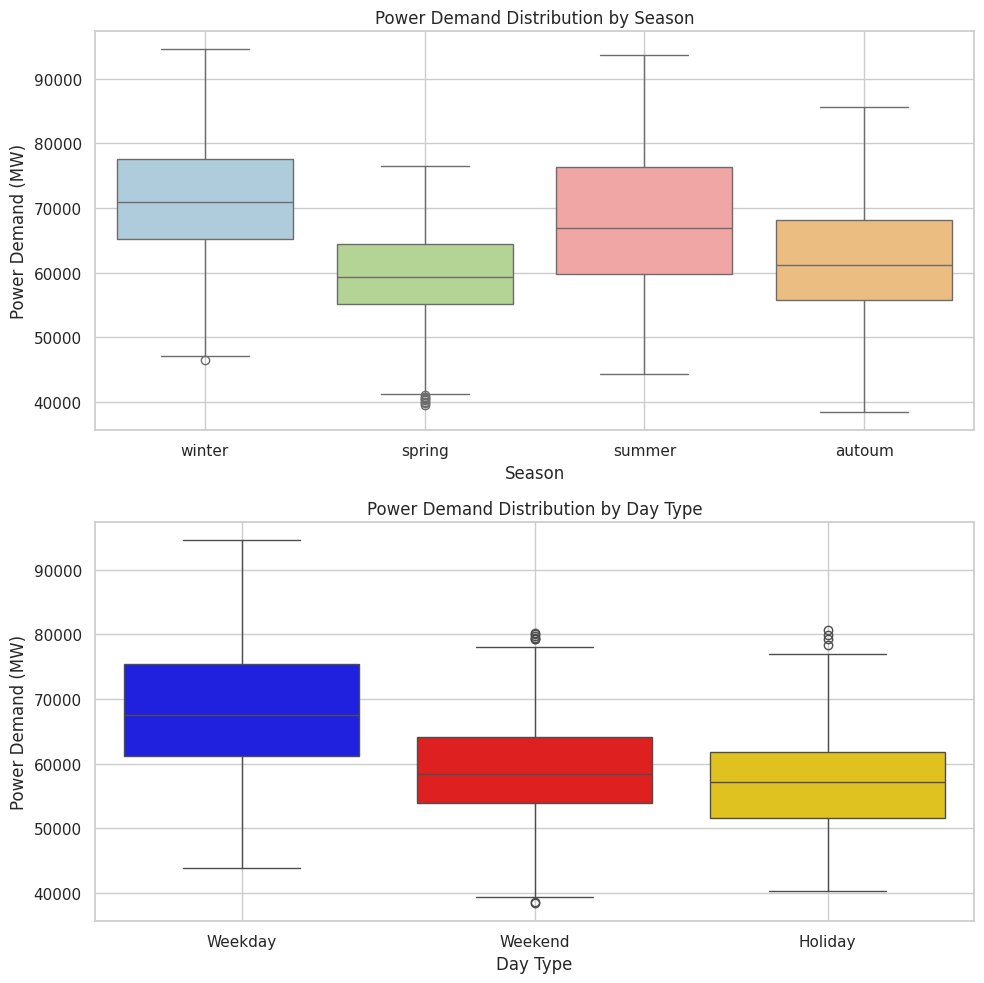

In [194]:
fig, axs = plt.subplots(2, 1, figsize=(10, 10))

# Boxplot 1: Season
sns.boxplot(
    data=df_real2_ex,
    x="season",
    y="power demand(MW)",
    palette={"spring": "#b2df8a", "summer": "#fb9a99", "autoum": "#fdbf6f", "winter": "#a6cee3"},
    ax=axs[0]
)
axs[0].set_title("Power Demand Distribution by Season")
axs[0].set_xlabel("Season")
axs[0].set_ylabel("Power Demand (MW)")
axs[0].grid(True)

# Boxplot 2: Day Type
df_real2_ex["day_label"] = df_real2_ex["holiday_name"].apply(lambda x: "Holiday" if x != "day" else None)
df_real2_ex["day_label"] = df_real2_ex["day_label"].fillna(
    df_real2_ex["day_type"].map({"weekday": "Weekday", "weekend": "Weekend"})
)

sns.boxplot(
    data=df_real2_ex,
    x="day_label",
    y="power demand(MW)",
    palette={"Weekday": "blue", "Weekend": "red", "Holiday": "gold"},
    ax=axs[1]
)
axs[1].set_title("Power Demand Distribution by Day Type")
axs[1].set_xlabel("Day Type")
axs[1].set_ylabel("Power Demand (MW)")
axs[1].grid(True)

plt.tight_layout()
plt.show()
